
# Lab 4: FDM-diffusion

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
3. Do a gif for the temperature in time (bonus!)

# Solución

# Punto 1:

In [1]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [2]:

def Diffusion2D(V_ini, nx, ny, dt, D, dx2, dy2, dx, a):

    u0 = V_ini.copy()
    u = u0.copy()

    # 1. Difusión: solamente puntos interiores
    for i in range(1, nx-1):
        for j in range(1, ny-1):

            uxx = (u0[i+1,j] - 2*u0[i,j] + u0[i-1,j])/dx2
            uyy = (u0[i,j+1] - 2*u0[i,j] + u0[i,j-1])/dy2

            u[i,j] = u0[i,j] + dt*D*(uxx + uyy)

    # 2. Condiciones de frontera
    for i in range(nx):
        x = i*dx

        u[i,ny-1] = 273.15 + 100*np.sin(3*np.pi*x/a)

    return u

dt = 5.602240896358545e-05

Placa de 20x10 mm con frontera T(x,b) sinusoidal. Evolucion de 11.20448179271709 ms


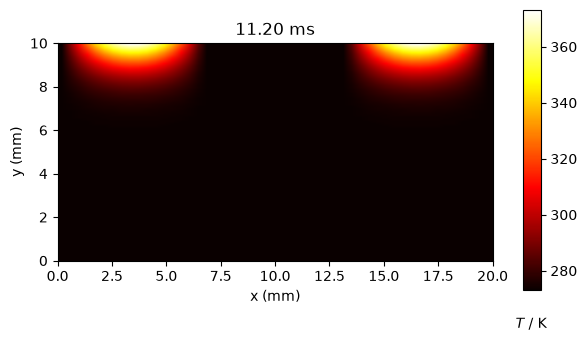

In [3]:
# plate size, mm
a = 20.0
b = 10.0
# intervals in x, y directions, mm
dx = 0.40
dy = 0.1

# Thermal diffusivity of aluminum, mm2.s-1 D=1/alpha
D = 84.0

T = 273.15 # in Kelvin

nx, ny = int(a/dx)+1 , int(b/dy)+1

dx2, dy2 = dx*dx, dy*dy

dt = dx2*dy2 / (2*D*(dx2 + dy2)) # maximum dt allowed (theory)
print('dt =', dt)

u0 = T*np.ones((nx, ny)) # Se crea la grid

# Condición inicial de la frontera superior a t = 0
for i in range(nx):
    x = i*dx
    u0[i, ny-1] = 273.15 + 100*np.sin(3*np.pi*x/a)

u = u0.copy()

# Number of time steps
nsteps = 200

# timesteps
fig, ax = plt.subplots(figsize=(6,4))

for m in range(nsteps):
    u = Diffusion2D(u0, nx, ny, dt, D, dx2, dy2, dx, a)
    u0 = u.copy()

# Se grafica u.T con origin='lower' y extent para orientar ejes x e y correctamente
im = ax.imshow(u.T, cmap="hot", origin="lower", extent=[0, a, 0, b], vmin=273.15, vmax=373.15, interpolation="bilinear")

ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title("{:.2f} ms".format(nsteps*dt*1000))

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / K", labelpad=20)
fig.colorbar(im, cax=cbar_ax)

print('\nPlaca de 20x10 mm con frontera T(x,b) sinusoidal. Evolucion de', nsteps*dt*1000, 'ms')
plt.show()


Calculando estado estático (Punto 1)...
Calculando solución analítica (Punto 2)...


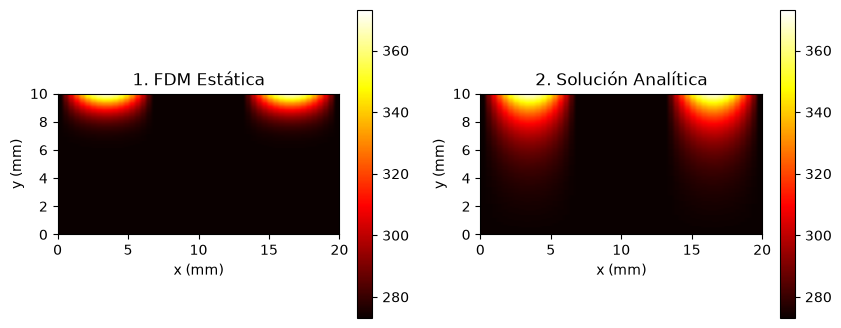

In [4]:
# Punto 2
print('\nCalculando estado estático (Punto 1)...')
u_estatico = u0.copy()

print('Calculando solución analítica (Punto 2)...')
u_analitico = T*np.ones((nx, ny))

for i in range(nx):
    for j in range(ny):
        x = i*dx
        y = j*dy
        # Fórmula matemática de la solución a la ecuación de Laplace
        u_analitico[i,j] = 273.15 + 100*np.sin(3*np.pi*x/a) * (np.sinh(3*np.pi*y/a) / np.sinh(3*np.pi*b/a))

# Grafia: estática y la analítica juntas 
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

im1 = ax1.imshow(u_estatico.T, cmap="hot", origin="lower", extent=[0, a, 0, b], vmin=273.15, vmax=373.15)
ax1.set_title("1. FDM Estática")
ax1.set_xlabel("x (mm)")
ax1.set_ylabel("y (mm)")
fig1.colorbar(im1, ax=ax1)

im2 = ax2.imshow(u_analitico.T, cmap="hot", origin="lower", extent=[0, a, 0, b], vmin=273.15, vmax=373.15)
ax2.set_title("2. Solución Analítica")
ax2.set_xlabel("x (mm)")
ax2.set_ylabel("y (mm)")
fig1.colorbar(im2, ax=ax2)

plt.show()


Placa de 20x10 mm con frontera T(x,b) sinusoidal. Evolucion de 11.20448179271709 ms


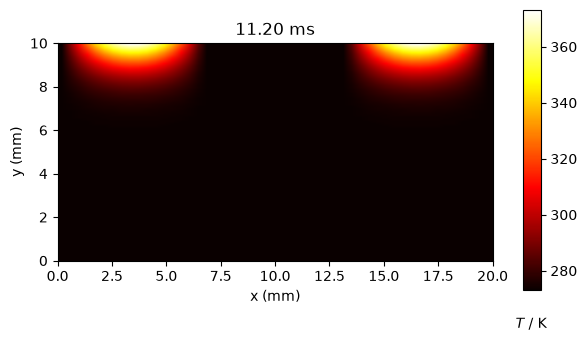

In [6]:
# Punto 3 y 4



u0_dyn = u0.copy() 

# Number of time steps
nsteps = 200

# timesteps
fig, ax = plt.subplots(figsize=(6,4))

# Configuración de la gráfica
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title("{:.2f} ms".format(nsteps*dt*1000))
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / K", labelpad=20)

im_base = ax.imshow(u0_dyn.T, cmap="hot", origin="lower", extent=[0, a, 0, b], vmin=273.15, vmax=373.15, interpolation="bilinear")
fig.colorbar(im_base, cax=cbar_ax)

frames = [] # Añadimos esta lista vacía para ir guardando las "fotos"


for m in range(nsteps):
    u = Diffusion2D(u0_dyn, nx, ny, dt, D, dx2, dy2, dx, a)
    u0_dyn = u.copy()
    
    # En lugar de mostrar solo el último frame, guardamos el frame actual en la lista
    im = ax.imshow(u.T, cmap="hot", origin="lower", extent=[0, a, 0, b], vmin=273.15, vmax=373.15, interpolation="bilinear", animated=True)
    frames.append([im])

# Punto 4 (Bonus):
ani = animation.ArtistAnimation(fig, frames, interval=50, blit=True)



print('\nPlaca de 20x10 mm con frontera T(x,b) sinusoidal. Evolucion de', nsteps*dt*1000, 'ms')
plt.show()